In [1]:
import os
import stumpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

thai_font = fm.FontProperties(fname='Sarabun.ttf')

In [2]:
event_seq_df = pd.read_csv("outputs/01_time_series_transformation_and_pilot_visualization/event_sequence_core.csv")
prompt_seq_df = pd.read_csv("outputs/01_time_series_transformation_and_pilot_visualization/prompt_position_sequence_ready.csv")

In [3]:
def plot_matrix_profile(df, col_name, window_size, session_ids=None, prompt_id=None):
    df[col_name] = df[col_name].astype(float)
    df = df.groupby(["session_id", "prompt_id", "participant_code"]).agg(
        list_agg=(col_name, list)
    ).reset_index()
    df["mp"] = df["list_agg"].apply(lambda x: stumpy.stump(x, window_size))
    df["mp_val"] = df["mp"].apply(lambda x: x[:,0])
    df["mp_nn"] = df["mp"].apply(lambda x: x[:,1])
    df = df.drop(columns=["mp"])
    
    if session_ids and prompt_id:
        target_df = df[(df['session_id'].isin(session_ids)) & (df["prompt_id"] == prompt_id)]
    elif session_ids:
        target_df = df[df['session_id'].isin(session_ids)]
    else:
        return

    n = len(target_df)
    fig, axes = plt.subplots(n, 2, figsize=(15, 4 * n), dpi=100, sharex=False)
    
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, (idx, row) in enumerate(target_df.iterrows()):
        title_suffix = f"ID: {row['session_id']} | Participant: {row['participant_code']} | Prompt: {row['prompt_id']}"
        
        axes[i, 0].plot(row["list_agg"], color='blue', alpha=0.7)
        axes[i, 0].set_title(f"{col_name} - {title_suffix}", fontproperties=thai_font)
        axes[i, 0].set_ylabel("Value")
        axes[i, 0].grid(True, linestyle='--', alpha=0.5)

        axes[i, 1].plot(row["mp_val"], color='red')
        axes[i, 1].set_title(f"Matrix Profile - {title_suffix}", fontproperties=thai_font)
        axes[i, 1].set_ylabel("Distance")
        axes[i, 1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

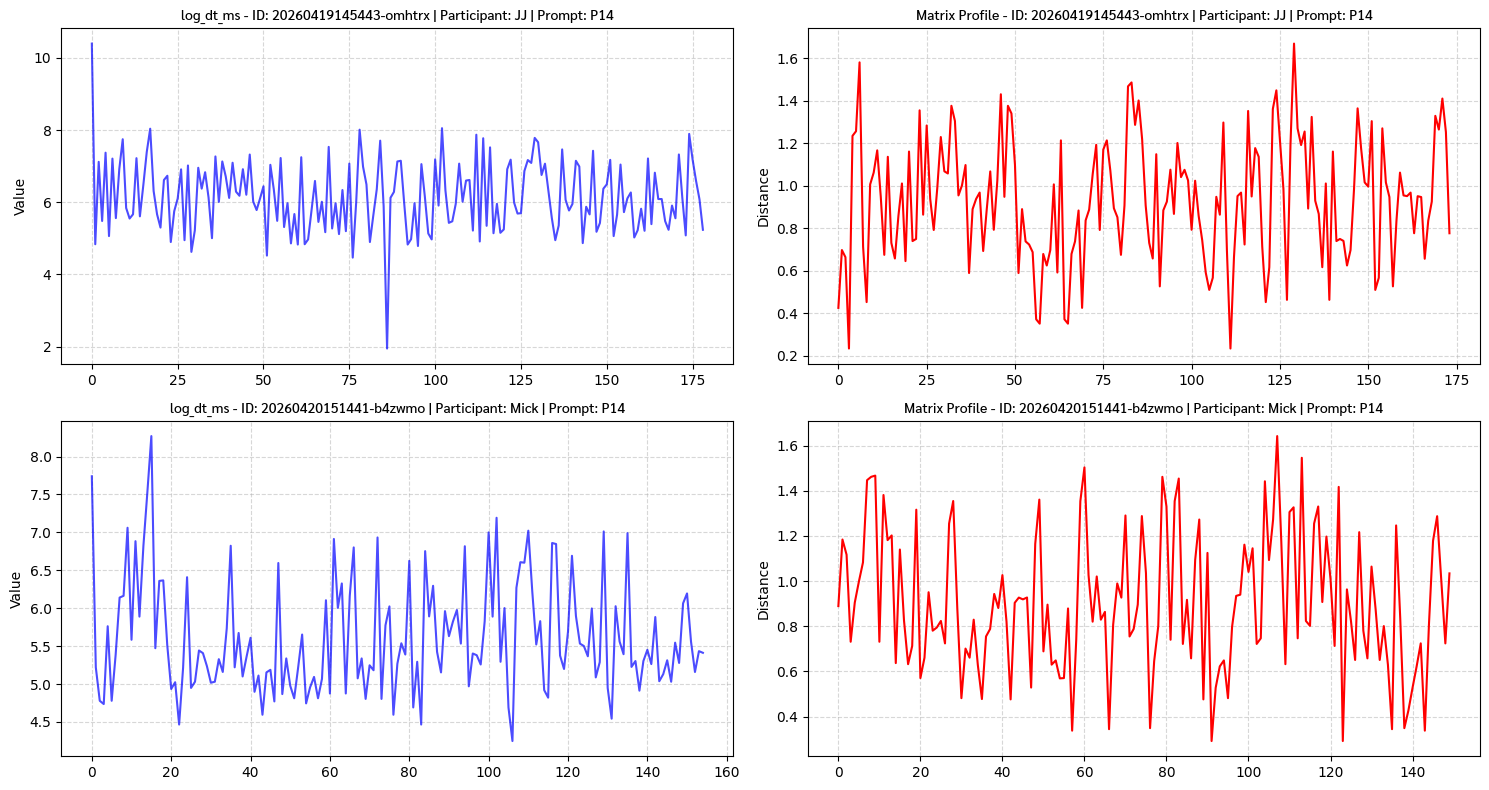

In [4]:
plot_matrix_profile(event_seq_df, "log_dt_ms", 6, session_ids=["20260420151441-b4zwmo", "20260419145443-omhtrx"], prompt_id="P14")

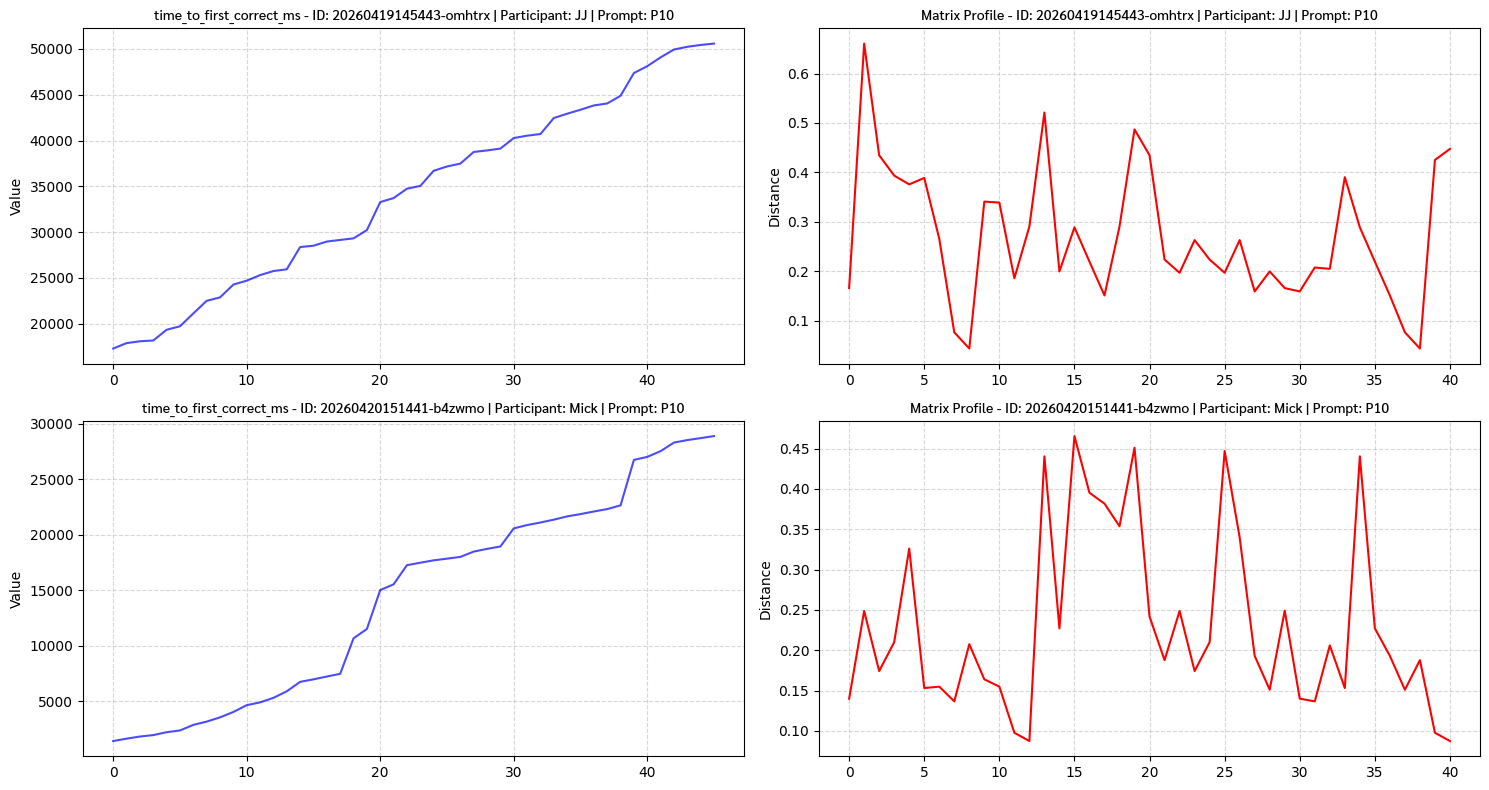

In [5]:
plot_matrix_profile(prompt_seq_df, "time_to_first_correct_ms", 6, session_ids=["20260420151441-b4zwmo", "20260419145443-omhtrx"], prompt_id="P10")

In [38]:
def plot_matrix_profile_AB(df, col_name, session_A, session_B, window_size, prompt_id):
    df[col_name] = df[col_name].astype(float)
    temp_df = df.groupby(["session_id", "prompt_id", "participant_code"]).agg(
        list_agg=(col_name, list)
    ).reset_index()
    
    row_A = temp_df[(temp_df["session_id"] == session_A) & (temp_df["prompt_id"] == prompt_id)]
    row_B = temp_df[(temp_df["session_id"] == session_B) & (temp_df["prompt_id"] == prompt_id)]

    signal_A = np.array(row_A["list_agg"].values[0])
    signal_B = np.array(row_B["list_agg"].values[0])
    p_code_A = row_A["participant_code"].values[0]
    p_code_B = row_B["participant_code"].values[0]

    mp = stumpy.stump(T_A=signal_A, m=window_size, T_B=signal_B, ignore_trivial=False)
    mp_val = mp[:, 0]

    fig, axes = plt.subplots(3, 1, figsize=(15, 10), dpi=100, sharex=False)
    
    axes[0].plot(signal_A, color='blue', alpha=0.7)
    axes[0].set_title(f"Signal A (Reference) - {session_A} | Participant: {p_code_A} | Prompt: {prompt_id}", fontproperties=thai_font)
    axes[0].set_ylabel(col_name)
    axes[0].grid(True, linestyle='--', alpha=0.5)

    axes[1].plot(signal_B, color='green', alpha=0.7)
    axes[1].set_title(f"Signal B (Target) - {session_B} | Participant: {p_code_B}", fontproperties=thai_font)
    axes[1].set_ylabel(col_name)
    axes[1].grid(True, linestyle='--', alpha=0.5)

    axes[2].plot(mp_val, color='red')
    axes[2].set_title(f"Matrix Profile (How A matches B) - Window Size: {window_size}", fontproperties=thai_font)
    axes[2].set_ylabel("Distance")
    axes[2].set_xlabel("Index in Signal A")
    axes[2].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

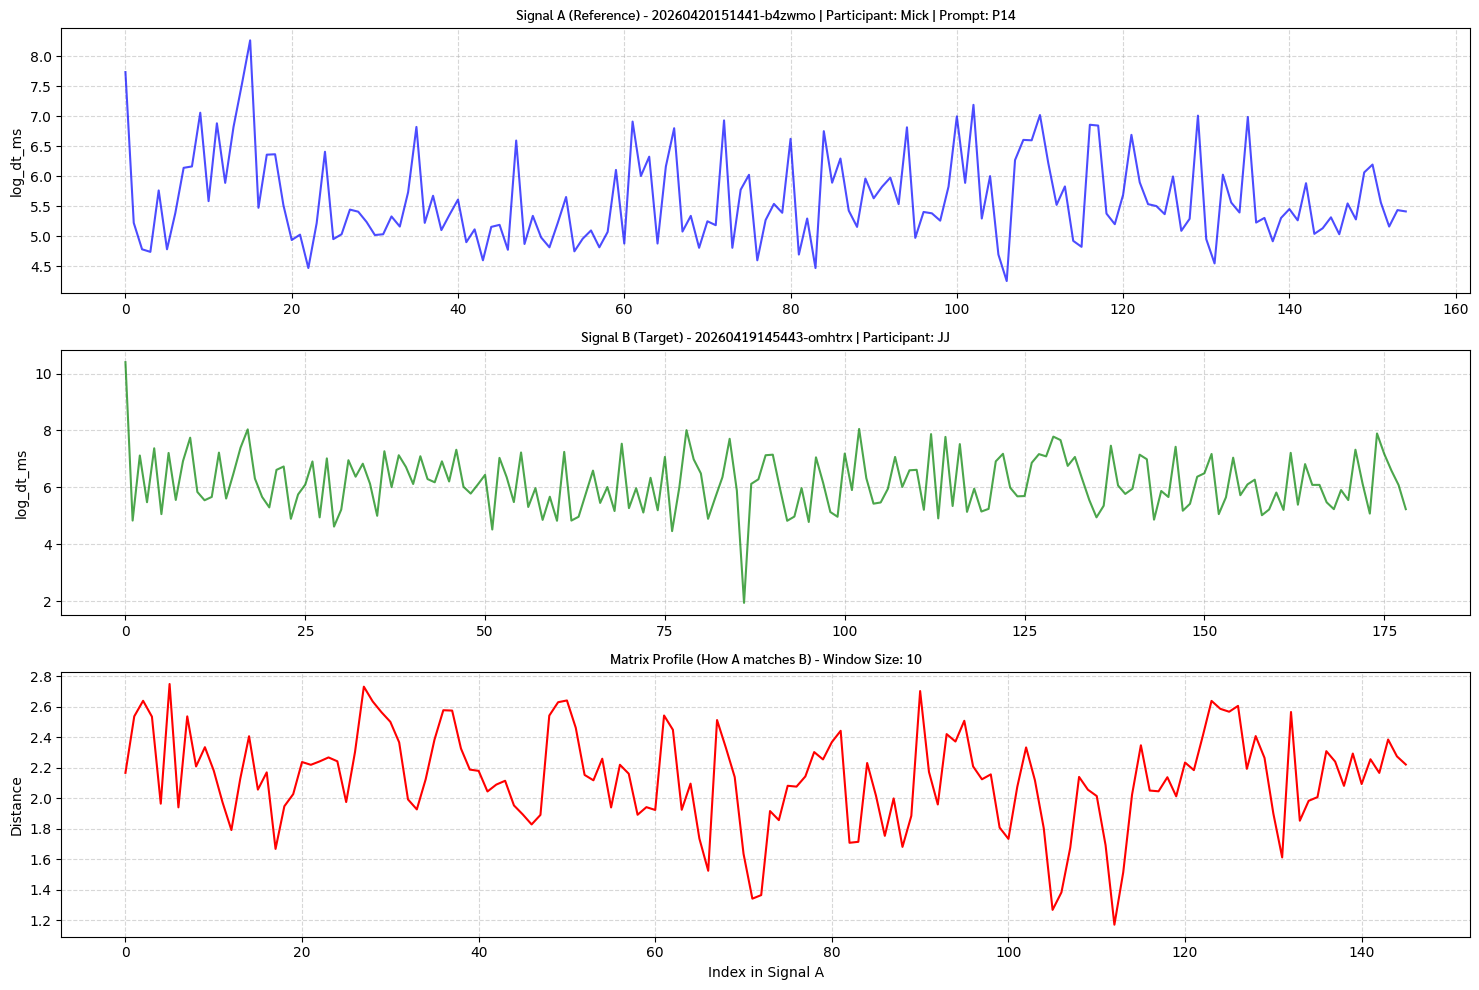

In [39]:
plot_matrix_profile_AB(event_seq_df, "log_dt_ms", "20260420151441-b4zwmo", "20260419145443-omhtrx", 10, "P14")